In [1]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
CSV_PATH = "cl_f.csv"  # <-- set this
DATE_COL = "Date"

df = pd.read_csv(CSV_PATH)

df[DATE_COL] = pd.to_datetime(df[DATE_COL], format="%d %b %Y", errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).set_index(DATE_COL)

for c in ["Open", "High", "Low", "Close", "Volume", "OpenInterest"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["Open", "High", "Low", "Close"]).copy()
df.tail()


,Open,High,Low,Close,Volume,OpenInterest
Date,,,,,,
2026-01-26,61.22,61.71,60.32,60.63,-0.44,0.0
2026-01-27,60.78,62.63,60.14,62.39,1.76,0.0
2026-01-28,62.58,63.57,62.07,63.21,0.82,0.0
2026-01-29,63.50,66.48,63.28,65.42,2.21,0.0
2026-01-30,65.53,66.10,63.65,65.21,-0.21,0.0


In [3]:
def atr(high, low, close, n=20):
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low).abs(),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(n).mean()

def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def donchian_channels(high, low, n):
    upper = high.rolling(n).max()
    lower = low.rolling(n).min()
    return upper, lower


In [4]:
def backtest_futures_trend_long_short(
    df,
    *,
    breakout_n=55,
    exit_n=20,
    atr_n=20,
    ema_span=200,
    use_ema_filter=True,
    target_annual_vol=0.20,
    max_leverage=2.0,
    cost_bps=2.0,
    slippage_bps=1.0,
    periods_per_year=252,
):
    px = df.copy()

    # Indicators
    px["ATR"] = atr(px["High"], px["Low"], px["Close"], n=atr_n)
    px["ATR_PCT"] = px["ATR"] / px["Close"]
    px["EMA"] = ema(px["Close"], span=ema_span)

    up, dn = donchian_channels(px["High"], px["Low"], n=breakout_n)
    px["DONCH_UP"] = up
    px["DONCH_DN"] = dn

    exit_up, exit_dn = donchian_channels(px["High"], px["Low"], n=exit_n)
    px["EXIT_UP"] = exit_up
    px["EXIT_DN"] = exit_dn

    # Breakout signals at close; trade next open
    long_entry  = px["Close"] > px["DONCH_UP"].shift(1)
    short_entry = px["Close"] < px["DONCH_DN"].shift(1)

    long_exit  = px["Close"] < px["EXIT_DN"].shift(1)
    short_exit = px["Close"] > px["EXIT_UP"].shift(1)

    if use_ema_filter:
        long_ok  = px["Close"] > px["EMA"]
        short_ok = px["Close"] < px["EMA"]
    else:
        long_ok  = pd.Series(True, index=px.index)
        short_ok = pd.Series(True, index=px.index)

    # Position state machine: -1, 0, +1
    pos = pd.Series(0.0, index=px.index)
    state = 0  # -1 short, 0 flat, +1 long

    for i in range(len(px.index)):
        if i == 0:
            pos.iloc[i] = 0.0
            continue

        if state == 0:
            # Entries (if both trigger, ignore / stay flat; rare but possible)
            le = bool(long_entry.iloc[i] and long_ok.iloc[i])
            se = bool(short_entry.iloc[i] and short_ok.iloc[i])

            if le and not se:
                state = 1
            elif se and not le:
                state = -1

        elif state == 1:
            # Long exits; optional flip-to-short if breakout occurs
            if bool(long_exit.iloc[i]) or (use_ema_filter and not bool(long_ok.iloc[i])):
                state = 0
            else:
                # allow reversal on strong opposite breakout
                if bool(short_entry.iloc[i] and short_ok.iloc[i]):
                    state = -1

        elif state == -1:
            # Short exits; optional flip-to-long if breakout occurs
            if bool(short_exit.iloc[i]) or (use_ema_filter and not bool(short_ok.iloc[i])):
                state = 0
            else:
                if bool(long_entry.iloc[i] and long_ok.iloc[i]):
                    state = 1

        pos.iloc[i] = float(state)

    # Vol targeting
    target_daily_vol = target_annual_vol / np.sqrt(periods_per_year)
    est_daily_vol = px["ATR_PCT"].replace(0, np.nan)

    lev = (target_daily_vol / est_daily_vol).clip(upper=max_leverage).fillna(0.0)

    # Execute at next open
    pos_exec = pos.shift(1).fillna(0.0)
    lev_exec = lev.shift(1).fillna(0.0)
    exposure = pos_exec * lev_exec  # signed exposure

    # Open-to-Open returns (consistent with open execution)
    r = px["Open"].pct_change().fillna(0.0)

    # Turnover cost on exposure changes
    turnover = exposure.diff().abs().fillna(0.0)
    total_bps = cost_bps + slippage_bps
    costs = turnover * (total_bps / 1e4)

    strat_ret = exposure * r - costs

    out = pd.DataFrame(index=px.index)
    out["ret"] = strat_ret
    out["pos"] = pos
    out["lev"] = lev
    out["exposure"] = exposure
    out["turnover"] = turnover
    out["costs"] = costs
    out["equity"] = (1 + out["ret"]).cumprod()

    # Benchmark: buy&hold open-open (unlevered)
    out["bh_ret"] = r
    out["bh_equity"] = (1 + out["bh_ret"]).cumprod()

    # Diagnostics
    out["Close"] = px["Close"]
    out["EMA"] = px["EMA"]
    out["DONCH_UP"] = px["DONCH_UP"]
    out["DONCH_DN"] = px["DONCH_DN"]
    out["EXIT_UP"] = px["EXIT_UP"]
    out["EXIT_DN"] = px["EXIT_DN"]
    out["ATR_PCT"] = px["ATR_PCT"]

    return out


In [5]:


# -----------------------------
# Metrics
# -----------------------------
def _max_dd(equity: pd.Series) -> float:
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())

def _cagr(equity: pd.Series, periods_per_year=252) -> float:
    n = len(equity)
    if n <= 1:
        return np.nan
    years = n / periods_per_year
    if years <= 0:
        return np.nan
    return float(equity.iloc[-1] ** (1 / years) - 1)

def _sharpe(returns: pd.Series, periods_per_year=252) -> float:
    s = returns.std(ddof=0)
    if s == 0 or np.isnan(s):
        return np.nan
    return float((returns.mean() / s) * np.sqrt(periods_per_year))

def tearsheet_stats_ls(bt: pd.DataFrame, periods_per_year=252) -> dict:
    rets = bt["ret"].dropna()
    eq = bt["equity"].dropna()
    if len(eq) < 2:
        return {}

    cagr = _cagr(eq, periods_per_year)
    mdd = _max_dd(eq)
    sh = _sharpe(rets, periods_per_year)
    calmar = cagr / abs(mdd) if (mdd < 0 and not np.isnan(cagr)) else np.nan

    exp = bt["exposure"].fillna(0.0)
    turnover = bt["turnover"].fillna(0.0)
    costs = bt["costs"].fillna(0.0)

    return {
        "CAGR": cagr,
        "Sharpe": sh,
        "MaxDD": mdd,
        "Calmar": calmar,
        "Vol(ann)": float(rets.std(ddof=0) * np.sqrt(periods_per_year)),
        "PctTimeLong": float((exp > 0).mean()),
        "PctTimeShort": float((exp < 0).mean()),
        "PctTimeFlat": float((exp == 0).mean()),
        "AvgAbsExposure": float(exp.abs().mean()),
        "AvgTurnover": float(turnover.mean()),
        "TotalCosts(%)": float(costs.sum() * 100),
    }

# -----------------------------
# Scoring (tune this!)
# -----------------------------
def score_row(r: dict) -> float:
    """
    Higher is better.
    - Reward Sharpe + CAGR
    - Penalize MaxDD magnitude + turnover + too-much time in market (optional)
    """
    if any(pd.isna(r.get(k)) for k in ["Sharpe", "CAGR", "MaxDD"]):
        return -np.inf

    # Optional: discourage being always in the market (often hides overfitting)
    pct_in_mkt = 1.0 - r["PctTimeFlat"]

    return (
        1.0 * r["Sharpe"]
        + 2.0 * r["CAGR"]
        - 1.0 * abs(r["MaxDD"])
        - 5.0 * r["AvgTurnover"]
        - 0.2 * pct_in_mkt
    )

# -----------------------------
# Grid (edit freely)
# -----------------------------
PARAM_GRID = {
    "breakout_n":     [20, 40, 55, 80],
    "exit_n":         [10, 20, 30],
    "atr_n":          [14, 20],
    "ema_span":       [100, 200],
    "use_ema_filter": [True, False],
    "target_annual_vol": [0.12, 0.20],
    "max_leverage":   [1.0, 2.0],
    # keep costs fixed outside grid by default
}

COST_BPS = 2.0
SLIPPAGE_BPS = 1.0

# -----------------------------
# Run grid
# -----------------------------
keys = list(PARAM_GRID.keys())
grid = list(itertools.product(*[PARAM_GRID[k] for k in keys]))

rows = []
for vals in grid:
    params = dict(zip(keys, vals))

    bt = backtest_futures_trend_long_short(
        df,
        breakout_n=params["breakout_n"],
        exit_n=params["exit_n"],
        atr_n=params["atr_n"],
        ema_span=params["ema_span"],
        use_ema_filter=params["use_ema_filter"],
        target_annual_vol=params["target_annual_vol"],
        max_leverage=params["max_leverage"],
        cost_bps=COST_BPS,
        slippage_bps=SLIPPAGE_BPS,
    )

    st = tearsheet_stats_ls(bt)
    if not st:
        continue

    row = {**params, **st}
    row["Score"] = score_row(row)
    rows.append(row)

res_ls = pd.DataFrame(rows).sort_values("Score", ascending=False).reset_index(drop=True)

display(res_ls.head(30))
print(f"Grid rows: {len(res_ls)} / {len(grid)}")


,breakout_n,exit_n,atr_n,ema_span,use_ema_filter,target_annual_vol,max_leverage,CAGR,Sharpe,MaxDD,Calmar,Vol(ann),PctTimeLong,PctTimeShort,PctTimeFlat,AvgAbsExposure,AvgTurnover,TotalCosts(%),Score
0,20,10,20,100,True,0.20,2.0,0.186680,1.650906,-0.099334,1.879309,0.107184,0.348430,0.252295,0.399275,0.279213,0.036556,9.080464,1.622008
1,20,10,20,100,True,0.20,1.0,0.186460,1.650392,-0.099334,1.877095,0.107100,0.348430,0.252295,0.399275,0.278600,0.036434,9.050197,1.621664
2,20,10,14,100,True,0.20,2.0,0.185657,1.661937,-0.102057,1.819156,0.105870,0.348430,0.252295,0.399275,0.279611,0.038895,9.661500,1.616575
3,20,10,14,100,True,0.20,1.0,0.185405,1.661107,-0.102057,1.816687,0.105790,0.348430,0.252295,0.399275,0.278950,0.038676,9.607056,1.616337
4,20,10,14,100,True,0.12,1.0,0.109082,1.661937,-0.062353,1.749431,0.063522,0.348430,0.252295,0.399275,0.167767,0.023337,5.796900,1.580919
5,20,10,14,100,True,0.12,2.0,0.109082,1.661937,-0.062353,1.749431,0.063522,0.348430,0.252295,0.399275,0.167767,0.023337,5.796900,1.580919
6,20,10,20,100,True,0.12,2.0,0.109693,1.650906,-0.060657,1.808421,0.064311,0.348430,0.252295,0.399275,0.167528,0.021933,5.448278,1.579823
7,20,10,20,100,True,0.12,1.0,0.109693,1.650906,-0.060657,1.808421,0.064311,0.348430,0.252295,0.399275,0.167528,0.021933,5.448278,1.579823
8,20,10,14,200,True,0.20,1.0,0.164880,1.542578,-0.092674,1.779139,0.102358,0.327657,0.227899,0.444444,0.261161,0.034028,8.452633,1.498412
9,20,10,14,200,True,0.20,2.0,0.165062,1.542956,-0.092674,1.781094,0.102439,0.327657,0.227899,0.444444,0.261830,0.034236,8.504196,1.498114


Grid rows: 384 / 384


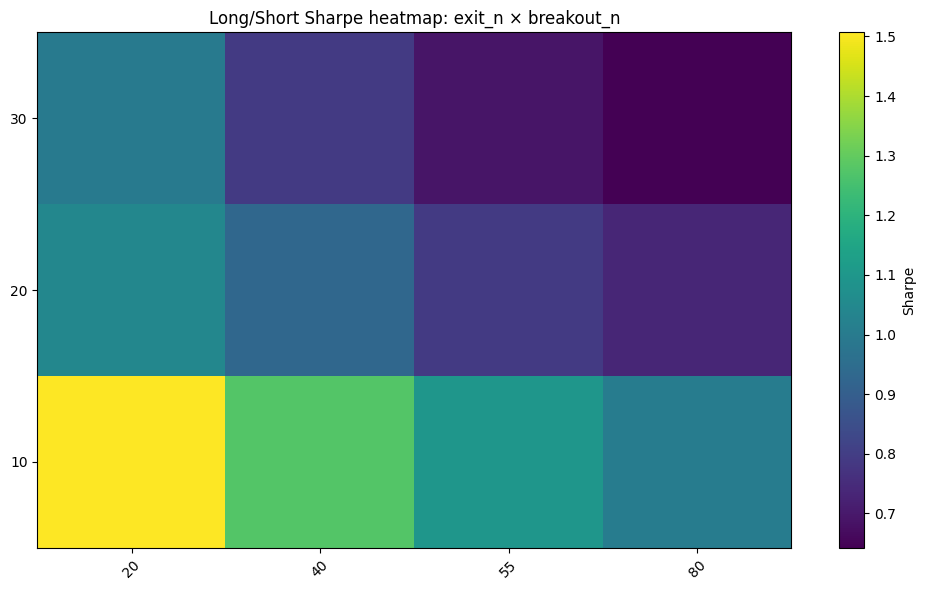

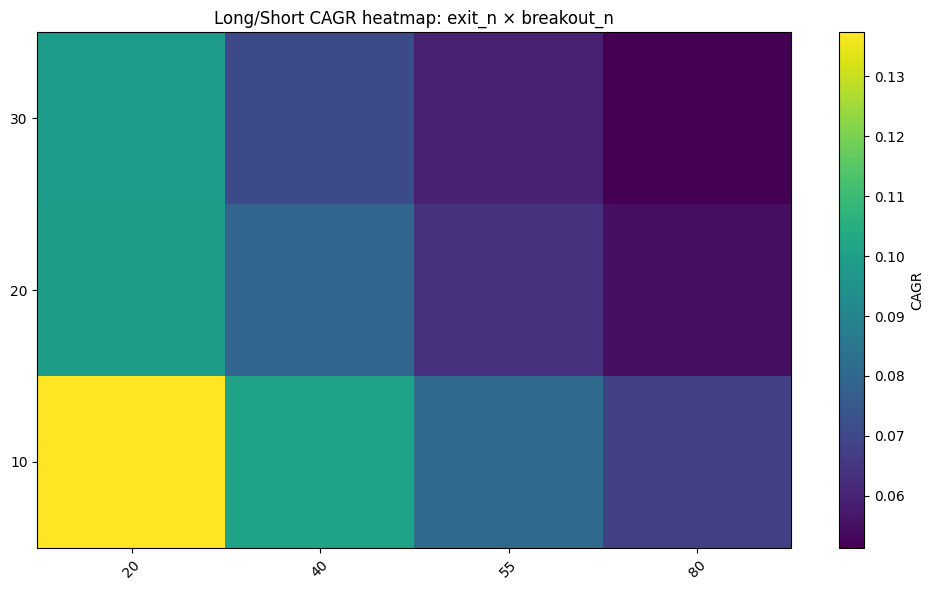

In [6]:
def plot_heatmap(df_res, x, y, value, agg="mean", title=None):
    pv = df_res.pivot_table(index=y, columns=x, values=value, aggfunc=agg)
    plt.figure(figsize=(10, 6))
    plt.imshow(pv.values, aspect="auto", origin="lower")
    plt.xticks(range(pv.shape[1]), pv.columns, rotation=45)
    plt.yticks(range(pv.shape[0]), pv.index)
    plt.colorbar(label=value)
    plt.title(title or f"{value} ({agg}) by {y} x {x}")
    plt.tight_layout()
    plt.show()
    return pv

_ = plot_heatmap(res_ls, x="breakout_n", y="exit_n", value="Sharpe", agg="mean",
                 title="Long/Short Sharpe heatmap: exit_n × breakout_n")

_ = plot_heatmap(res_ls, x="breakout_n", y="exit_n", value="CAGR", agg="mean",
                 title="Long/Short CAGR heatmap: exit_n × breakout_n")


Best params: {'breakout_n': 20, 'exit_n': 10, 'atr_n': 20, 'ema_span': 100, 'use_ema_filter': True, 'target_annual_vol': 0.2, 'max_leverage': 2.0}
Best stats: {'Score': 1.6220077204813725, 'CAGR': 0.1866801039287469, 'Sharpe': 1.6509059305006897, 'MaxDD': -0.09933443168310219, 'Calmar': 1.8793091254027188, 'PctTimeLong': 0.34842995169082125, 'PctTimeShort': 0.25229468599033816, 'PctTimeFlat': 0.3992753623188406, 'AvgAbsExposure': 0.2792127691336531, 'AvgTurnover': 0.03655581173149536, 'TotalCosts(%)': 9.080463634103449}


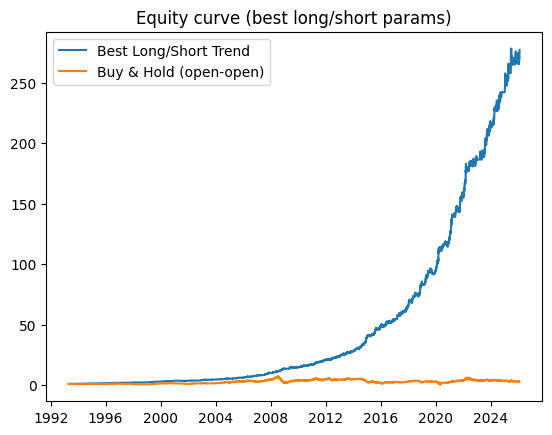

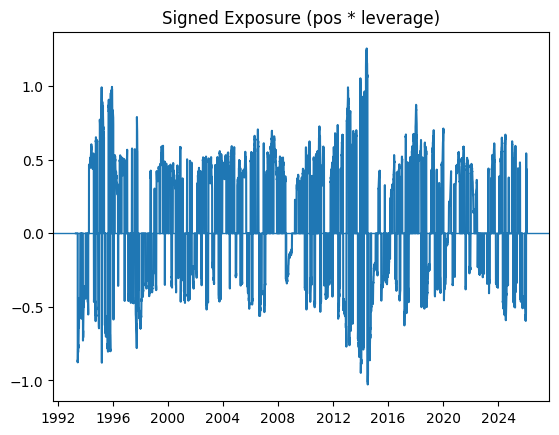

In [7]:
best = res_ls.iloc[0].to_dict()
best_params = {k: best[k] for k in PARAM_GRID.keys()}

print("Best params:", best_params)
print("Best stats:", {k: best[k] for k in [
    "Score","CAGR","Sharpe","MaxDD","Calmar",
    "PctTimeLong","PctTimeShort","PctTimeFlat",
    "AvgAbsExposure","AvgTurnover","TotalCosts(%)"
]})

bt_best_ls = backtest_futures_trend_long_short(
    df,
    breakout_n=best_params["breakout_n"],
    exit_n=best_params["exit_n"],
    atr_n=best_params["atr_n"],
    ema_span=best_params["ema_span"],
    use_ema_filter=best_params["use_ema_filter"],
    target_annual_vol=best_params["target_annual_vol"],
    max_leverage=best_params["max_leverage"],
    cost_bps=COST_BPS,
    slippage_bps=SLIPPAGE_BPS,
)

plt.figure()
plt.plot(bt_best_ls.index, bt_best_ls["equity"], label="Best Long/Short Trend")
plt.plot(bt_best_ls.index, bt_best_ls["bh_equity"], label="Buy & Hold (open-open)")
plt.title("Equity curve (best long/short params)")
plt.legend()
plt.show()

plt.figure()
plt.plot(bt_best_ls.index, bt_best_ls["exposure"])
plt.axhline(0, linewidth=1)
plt.title("Signed Exposure (pos * leverage)")
plt.show()
